In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
origin = pd.read_csv('orijinal_veri.csv')
origin.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [9]:
# Check missing values 
origin.isnull().sum().sum()

np.int64(0)

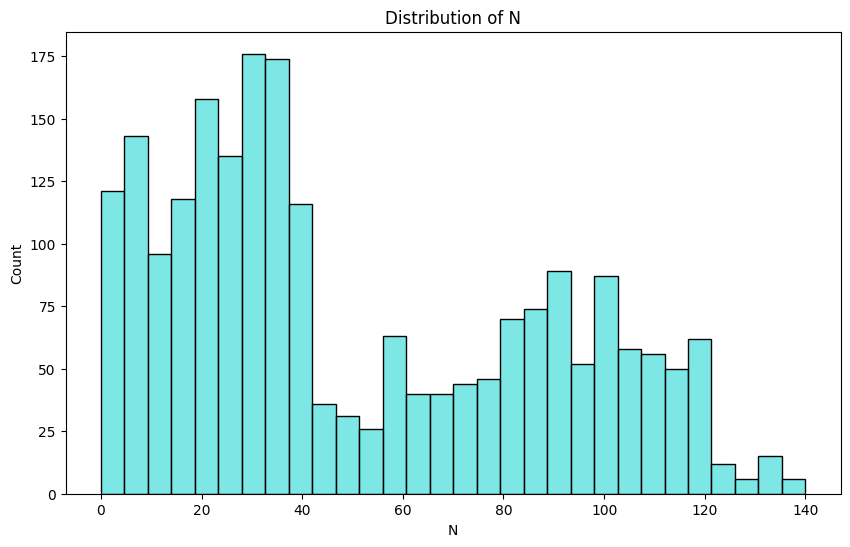

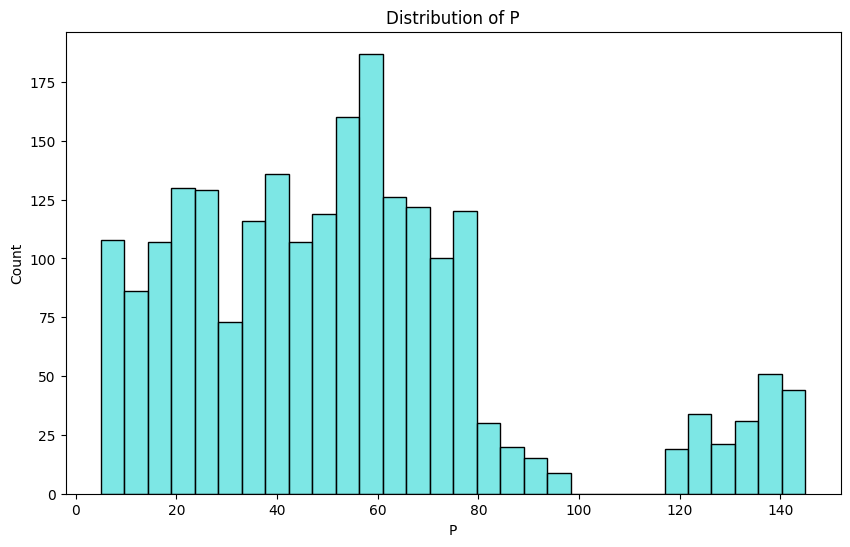

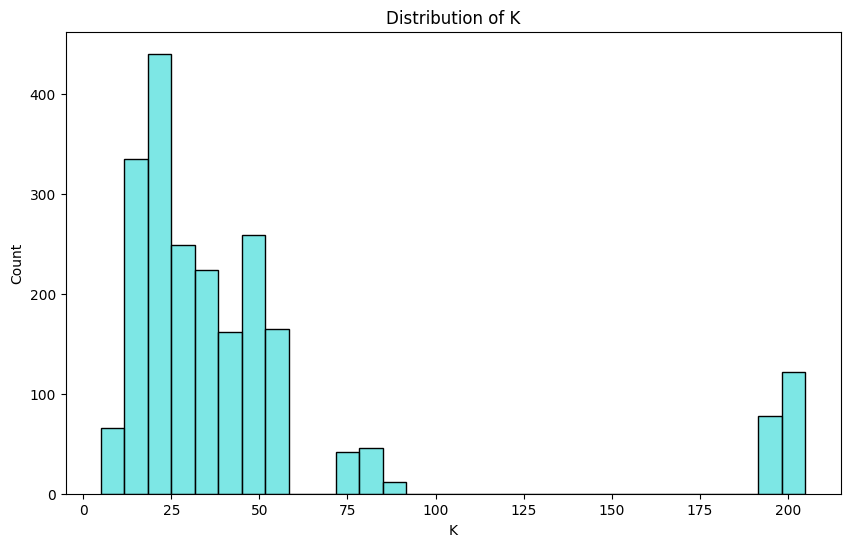

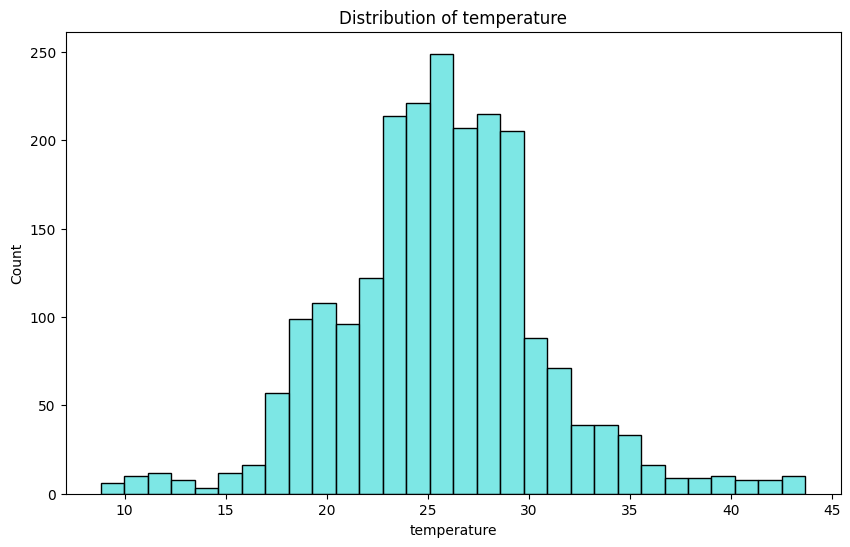

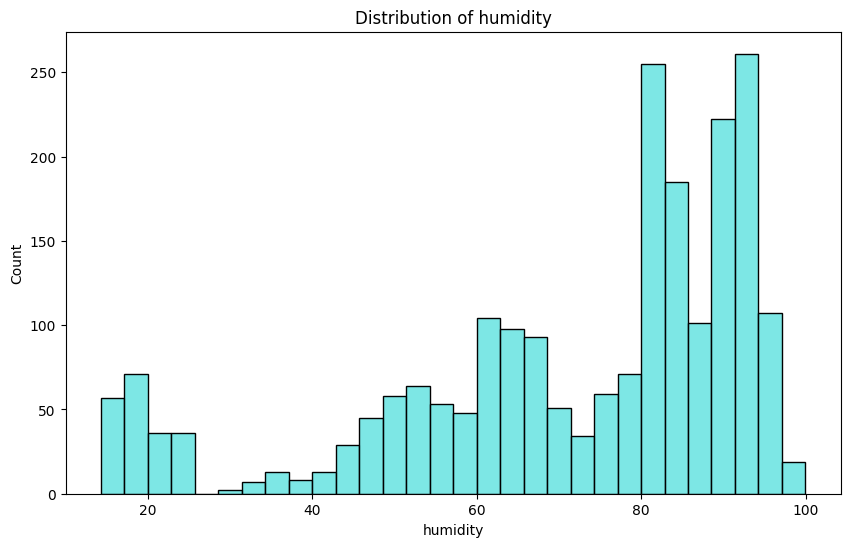

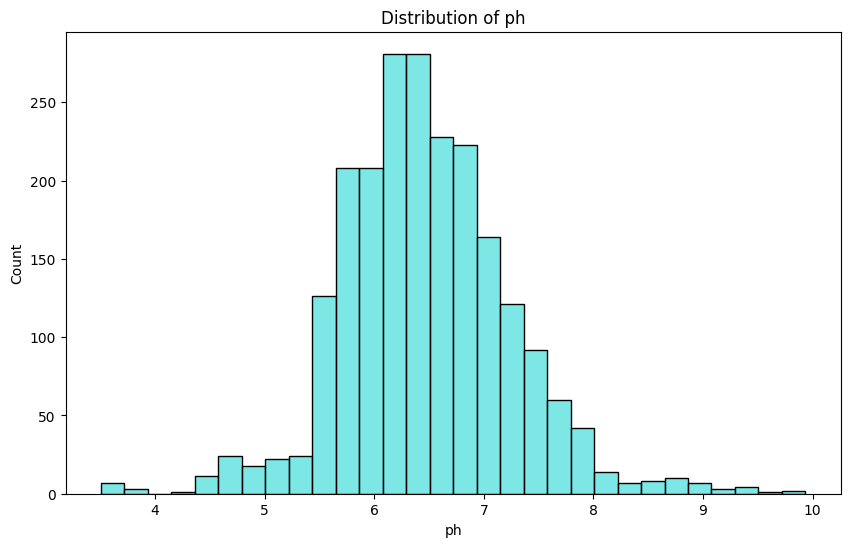

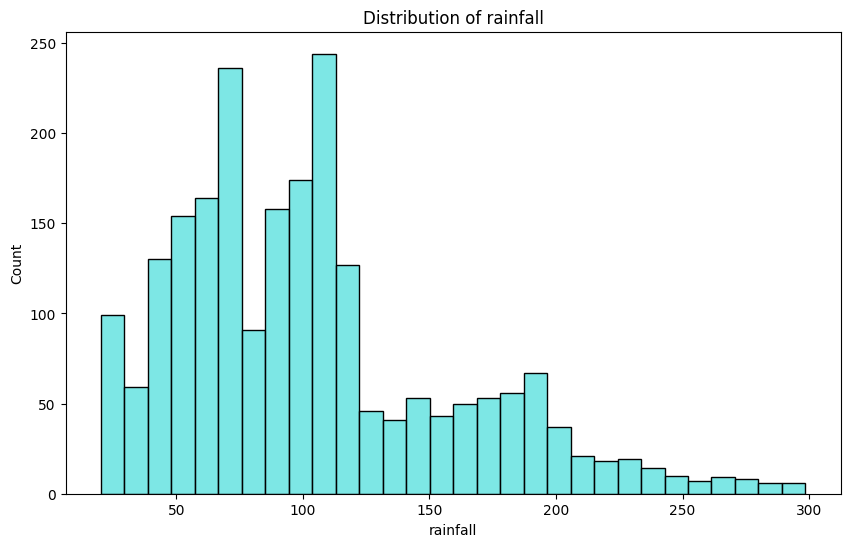

In [66]:
# Data visualization
for i in origin.columns.drop('label'):
    plt.figure(figsize=(10,6))
    sns.histplot(origin[i], bins=30, color='#52DFDD')
    plt.title(f'Distribution of {i}')
    plt.show()

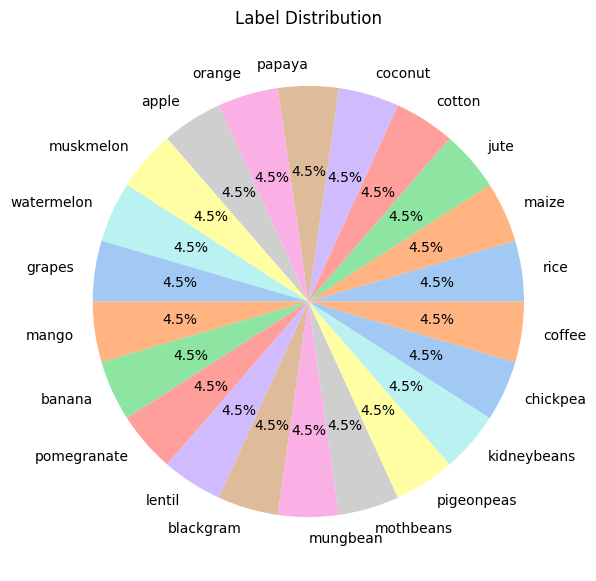

In [75]:
# Bar plot for label distribution
f = plt.figure(figsize=(20,7))
plt.pie(origin['label'].value_counts(), labels=origin['label'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Label Distribution')
plt.show()

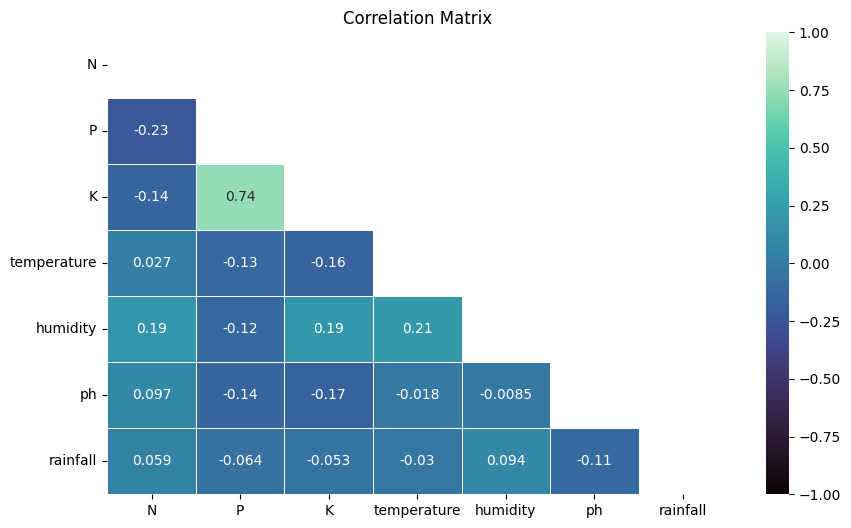

In [78]:
numeric_columns = origin.select_dtypes(include=[np.number]).columns
# Correlation Matrix 
mask = np.triu(origin[numeric_columns].corr())
plt.figure(figsize=(10,6))
sns.heatmap(origin[numeric_columns].corr(), annot=True, mask=mask, linewidths=0.5, cmap='mako',vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

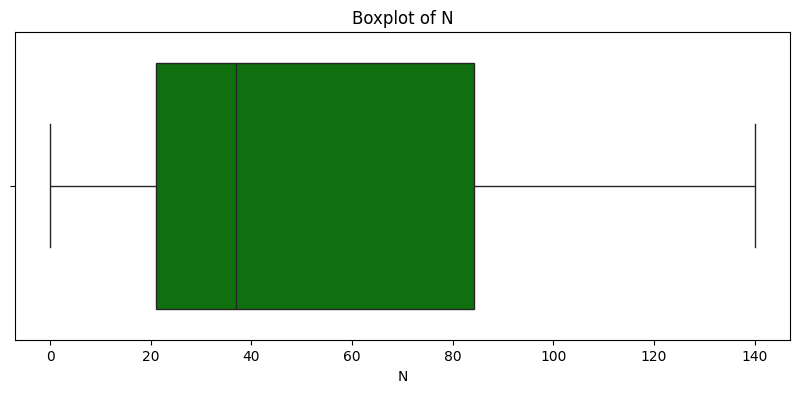

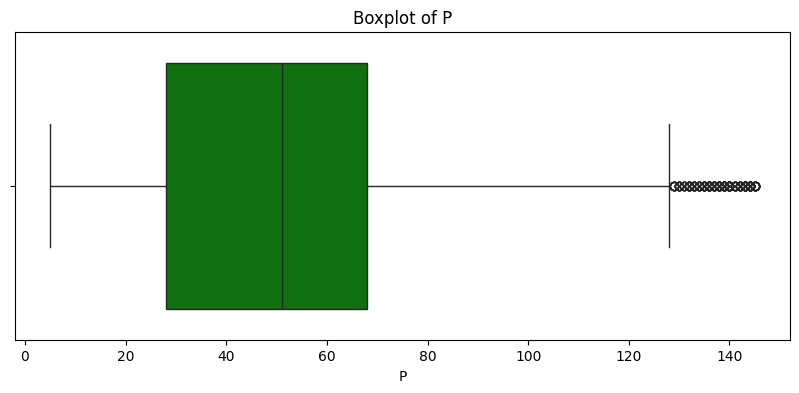

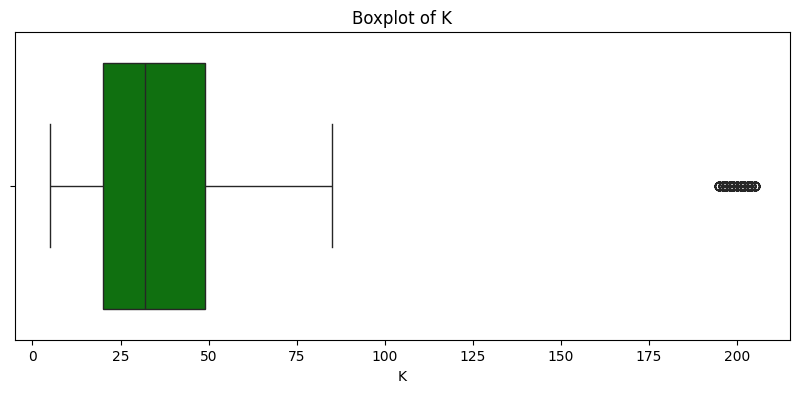

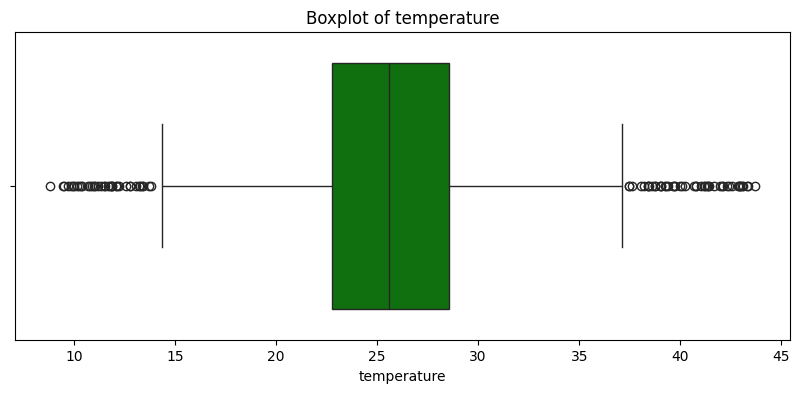

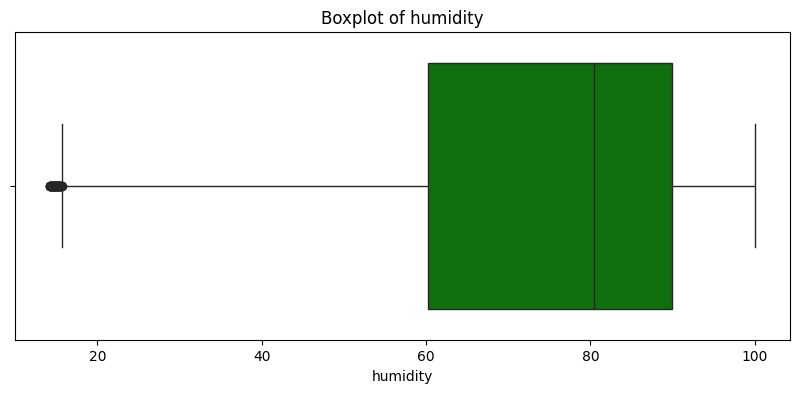

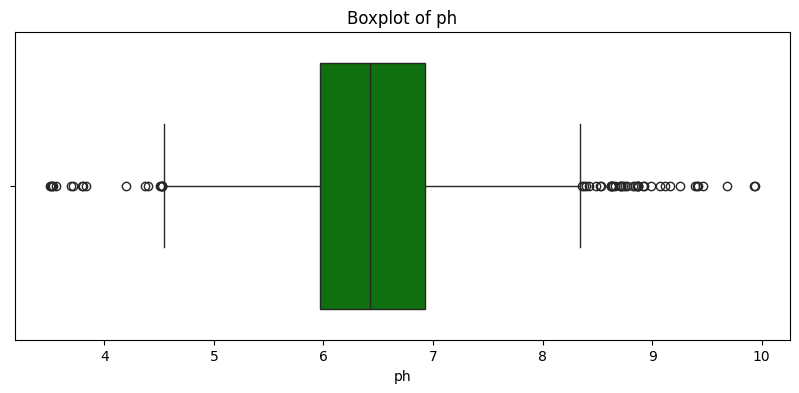

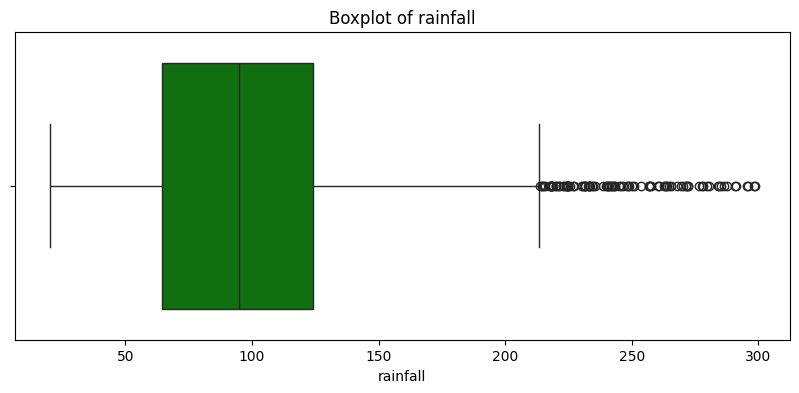

In [ ]:
# Check for outliers using boxplots
for i in origin.columns.drop('label'):
    plt.figure(figsize=(10,4))
    sns.boxplot(x=origin[i], color='green')
    plt.title(f'Boxplot of {i}')
    plt.show()


In [ ]:
# Normalize data using min-max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
origin_scaled = origin.copy()
origin_scaled[origin.columns.drop('label')] = scaler.fit_transform(origin_scaled[origin.columns.drop('label')])
origin_scaled.head()
# After normalization, range of the features set between 0 and 1

,N,P,K,temperature,humidity,ph,rainfall,label
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458,rice
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675,rice
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710,rice
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905,rice
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231,rice


In [6]:
# Outlier handling using IQR method 
numeric_columns = origin_scaled.select_dtypes(include=[np.number]).columns
Q1 = origin_scaled[numeric_columns].quantile(0.25)
Q3 = origin_scaled[numeric_columns].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
origin_no_outliers = origin_scaled[~((origin_scaled[numeric_columns] < lower_bound) | (origin_scaled[numeric_columns] > upper_bound)).any(axis=1)]
print(f"Original dataset shape: {origin_scaled.shape}")
print(f"Dataset shape after outlier removal: {origin_no_outliers.shape}")
# After outlier removal, the dataset has been reduced in size. This may help improve model performance by eliminating extreme values that could skew the results.

Original dataset shape: (2200, 8)
Dataset shape after outlier removal: (1768, 8)
